<a href="https://colab.research.google.com/github/tustus1022-ui/esaa/blob/main/ESAA_YB_WEEK16_transcription1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

아래 캐글을 필사 - 새롭게 공부한 내용(개념, 코드)을 함께 정리해두기를 추천합니다.

https://www.kaggle.com/code/tanmay111999/unsupervised-learning-3-6-clusters-k-means-eda

# **Unsupervised Learning: 3-6 Clusters | K-Means | EDA**

### Dataset Attributes
- CustomerID : Unique ID assigned to the customer
- Gender : Gender of the customer
- Age : Age of the customer
- Annual Income (k$) : Annual Income of the customer
- Spending Score (1-1000) : Score assigned by the mall based on customer behavior and spending nature

##  Import the Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

In [2]:
data = pd.read_csv('./Mall_Customers.csv')
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Info

In [3]:
data.shape

(200, 5)

In [4]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


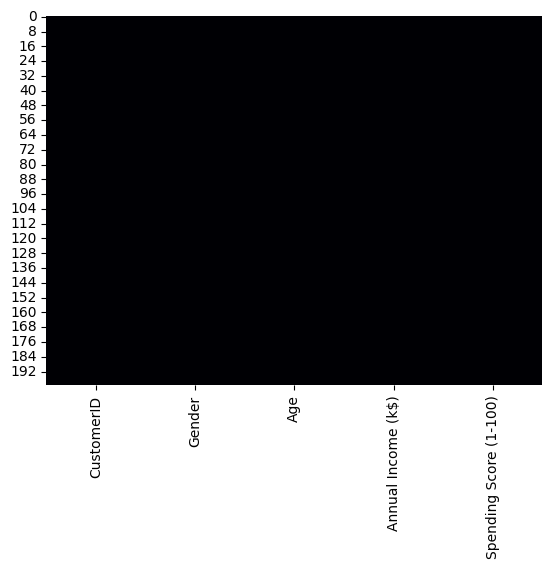

In [6]:
sns.heatmap(data.isnull(),cmap = 'magma',cbar = False);

- 데이터에 null 값이 없다.

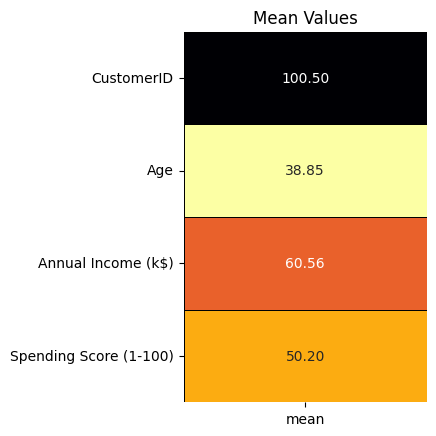

In [7]:
fig,ax = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5))

plt.subplot(1,1,1)
sns.heatmap(data.describe().T[['mean']],cmap = 'inferno_r',annot = True,fmt = '.2f',linecolor = 'black',linewidths = 0.4,cbar = False);
plt.title('Mean Values');

fig.tight_layout(pad = 3)

- 데이터셋의 평균 고객 연령은 30대 후반, 즉 38.85세입니다.
- 고객의 평균 연간 소득(k 달러)은 60.56으로, 2018년 미국 시민의 중위 소득인 63,000 달러에 약간 못 미치는 수준입니다.
- 쇼핑몰 고객의 지출 점수(1-100) 평균은 50.20으로 중심에 있습니다.

## Exploratory Data Analysis

### Dividing features into Numerical and Categorical

In [8]:
col = list(data.columns)
categorical_features = []
numerical_features = []
for i in col:
    if len(data[i].unique()) > 6:
        numerical_features.append(i)
    else:
        categorical_features.append(i)

print('Categorical Features :',*categorical_features)
print('Numerical Features :',*numerical_features)

Categorical Features : Gender
Numerical Features : CustomerID Age Annual Income (k$) Spending Score (1-100)


- 여기서 범주형 특징은 속성에 고유한 요소가 6개 미만인 경우 정의되며, 그렇지 않은 경우 수치적 특징입니다.
- 이 기능 분할에 대한 일반적인 접근 방식은 각 속성 요소의 데이터 유형을 기반으로 할 수도 있습니다.

예: 데이터 유형 = 정수, 속성 = 수치 특징; 데이터 유형 = 문자열, 속성 = 범주형 특징
- 이 데이터셋의 경우, 특징의 수가 적기 때문에 데이터셋을 수동으로 확인할 수도 있습니다.

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1 = data.copy(deep = True)

df1['Gender'] = le.fit_transform(df1['Gender'])

print('Label Encoder Transformation')
print(df1['Gender'].unique(),' = ',le.inverse_transform(df1['Gender'].unique()))

Label Encoder Transformation
[1 0]  =  ['Male' 'Female']


- 원본 데이터셋의 딥 카피와 젠더 텍스트 데이터를 인코딩하는 라벨 만들기
- 원본 데이터셋의 수정 사항은 이 심층 사본에서 강조되지 않을 것입니다.
- 따라서 우리는 시각화 및 모델링 목적으로 성별을 수치로 변환한 이 심층 데이터셋 사본을 사용합니다.

### Distribution of Categorical and Numerical Features

/tmp/ipykernel_3481/2039315377.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[categorical_features[i]],kde_kws = {'bw' : 1});
/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:2496: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=1`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)
/tmp/ipykernel_3481/2039315377.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to 

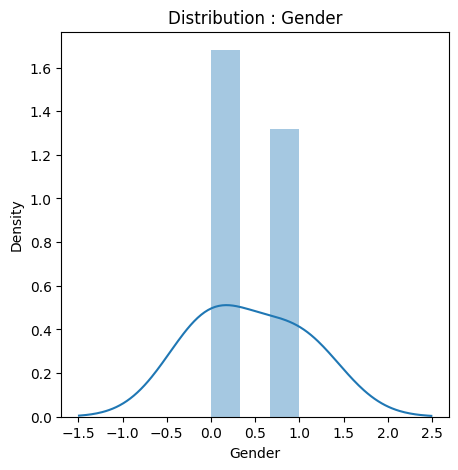

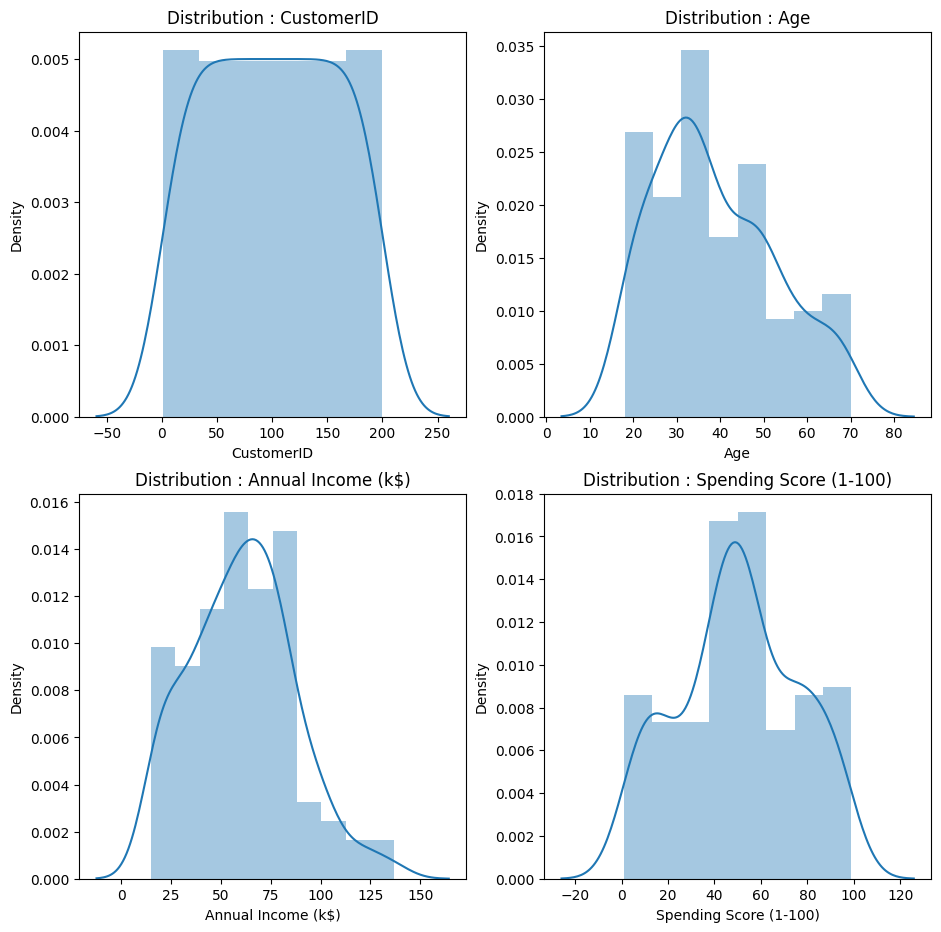

In [10]:
fig, ax = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5))
for i in range(len(categorical_features)):
    plt.subplot(1,1,i+1)
    sns.distplot(df1[categorical_features[i]],kde_kws = {'bw' : 1});
    title = 'Distribution : ' + categorical_features[i]
    plt.title(title)

fig, ax = plt.subplots(nrows = 2,ncols = 2,figsize = (11,11))
for i in range(len(numerical_features)):
    plt.subplot(2,2,i+1)
    sns.distplot(data[numerical_features[i]],)
    title = 'Distribution : ' + numerical_features[i]
    plt.title(title)
plt.show()

- 성별, 유일한 범주형 특징인 데이터는 정규 분포를 나타냅니다.
- 연령과 연간 소득(k$)의 분포는 긍정적이거나 오른쪽으로 치우쳐 있습니다.
- 지출 점수(1-100) 데이터 분포는 주식 차트에서 관찰되는 머리와 어깨 패턴과 유사합니다.
- 주식의 가격이 정점까지 상승했다가 이전 상승 추세의 바닥으로 다시 하락하는 것을 보여줍니다. 20과 80을 중심으로 두 개의 어깨가 형성되고 머리가 40~60 사이에 위치하는 것도 비슷한 현상을 관찰할 수 있습니다.
- 고객 ID 기능은 고객에게 태그된 숫자에 불과하므로 삭제하겠습니다.

In [11]:
numerical_features.remove('CustomerID')

### Categorical Features

/tmp/ipykernel_3481/3191743155.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Gender',data = df1,palette = colors,edgecolor = 'black');
/tmp/ipykernel_3481/3191743155.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female','Male'])


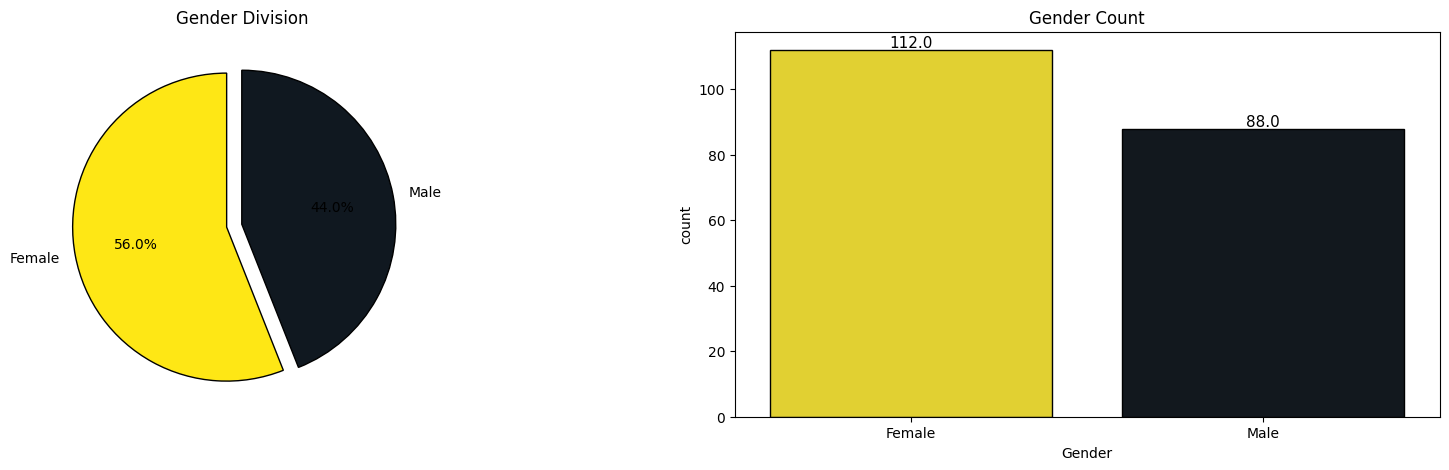

In [13]:
l = list(data['Gender'].value_counts())
circle = [l[0] / len(l) * 100, l[1] / len(l) * 100]
colors = ['#FEE715','#101820']


fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (20,5))

plt.subplot(1,2,1)
plt.pie(circle,labels = ['Female','Male'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Gender Division');

plt.subplot(1,2,2)
ax = sns.countplot(x='Gender',data = df1,palette = colors,edgecolor = 'black');
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.75,
            rect.get_height(), horizontalalignment='center', fontsize = 11)
plt.title('Gender Count')
ax.set_xticklabels(['Female','Male'])

plt.show()

- 위의 데이터셋에서는 여성 고객이 남성 고객보다 우위에 있습니다.

### Numerical Features vs Categorical Features

/tmp/ipykernel_3481/3178044531.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x = 'Gender',y = numerical_features[i],palette = colors,data = df1)
/tmp/ipykernel_3481/3178044531.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female','Male'])
/tmp/ipykernel_3481/3178044531.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x = 'Gender',y = numerical_features[i],palette = colors,data = df1)
/tmp/ipykernel_3481/3178044531.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xt

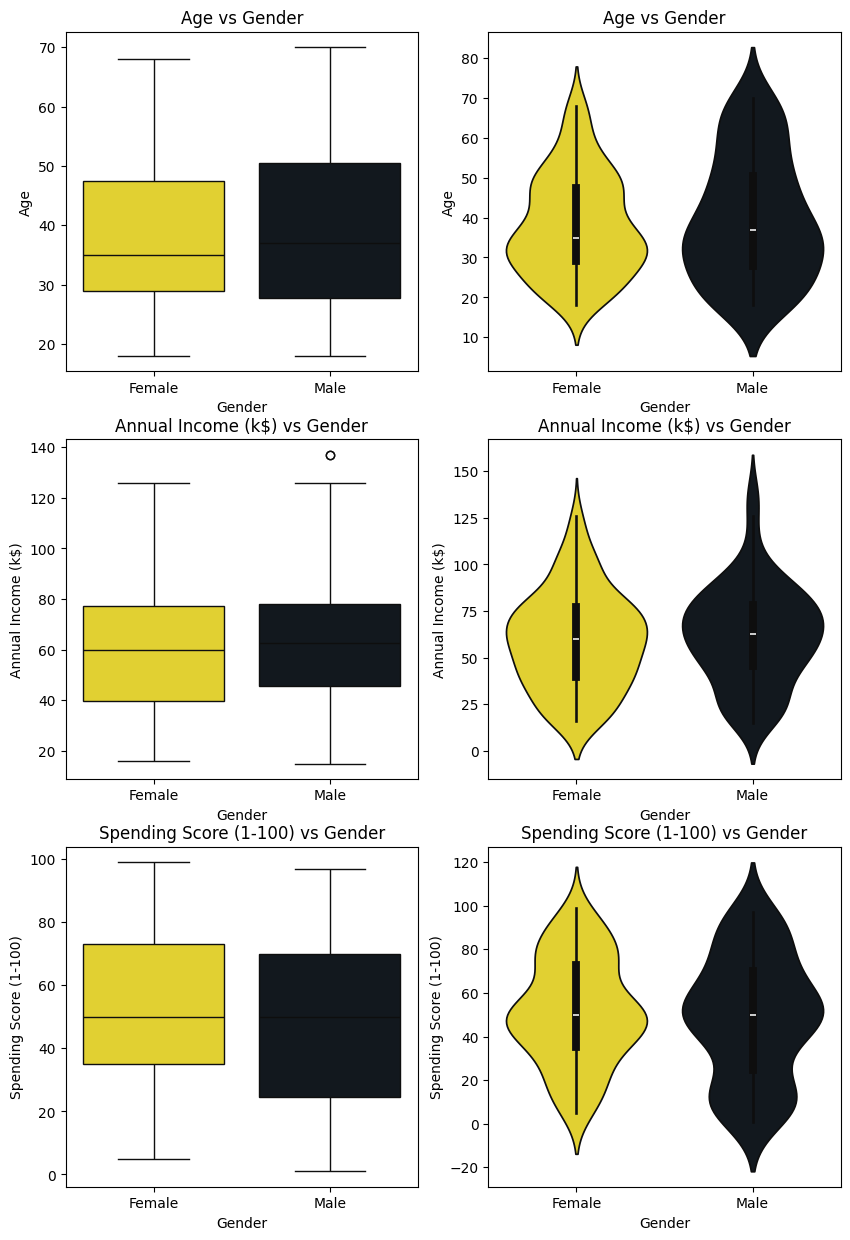

In [14]:
fig = plt.subplots(nrows = 3,ncols = 2,figsize = (10,15))
for i in range(len(numerical_features)):
    plt.subplot(3,2, (i * 2)  + 1)
    ax = sns.boxplot(x = 'Gender',y = numerical_features[i],palette = colors,data = df1)
    ax.set_xticklabels(['Female','Male'])
    title = numerical_features[i] + ' vs Gender'
    plt.title(title)

    plt.subplot(3,2,(i * 2) + 2)
    ax = sns.violinplot(x = 'Gender',y = numerical_features[i],palette = colors,data = df1)
    ax.set_xticklabels(['Female','Male'])
    title = numerical_features[i] + ' vs Gender'
    plt.title(title)

- 여성 고객의 연령대는 30세에서 50세 미만인 반면, 남성 고객의 연령대는 30세에서 50세 미만입니다.
- 두 성별 모두 30~35세에 팽대부가 관찰될 수 있습니다. 남성의 중간 연령은 여성보다 약간 높습니다.
- 연간 소득(k$)의 경우, 여성 고객의 소득은 40,000달러부터 시작하는 반면 남성 고객의 소득은 이 값을 초과합니다.
- 두 성별의 평균 연간 소득(k달러)은 약 6만 달러에 가깝습니다. 남성 고객의 연간 소득(k달러)은 여성 고객에 비해 약간의 이상치와 함께 정점에서 매우 급격히 감소합니다.
- 여성 고객과 남성 고객의 시작점이 각각 40점 바로 아래와 20점 바로 위임에도 불구하고 두 성별의 중간 지출 점수(1-100점)는 동일합니다.
- 두 성별 모두 특히 여성 고객의 중앙값에서 강한 팽대부를 나타냅니다. 그러나 남성 고객도 0~20 범위에서 작지만 유의미한 부풀림을 보입니다.

### Numerical Features vs Numerical Features w.r.t Categorical Features

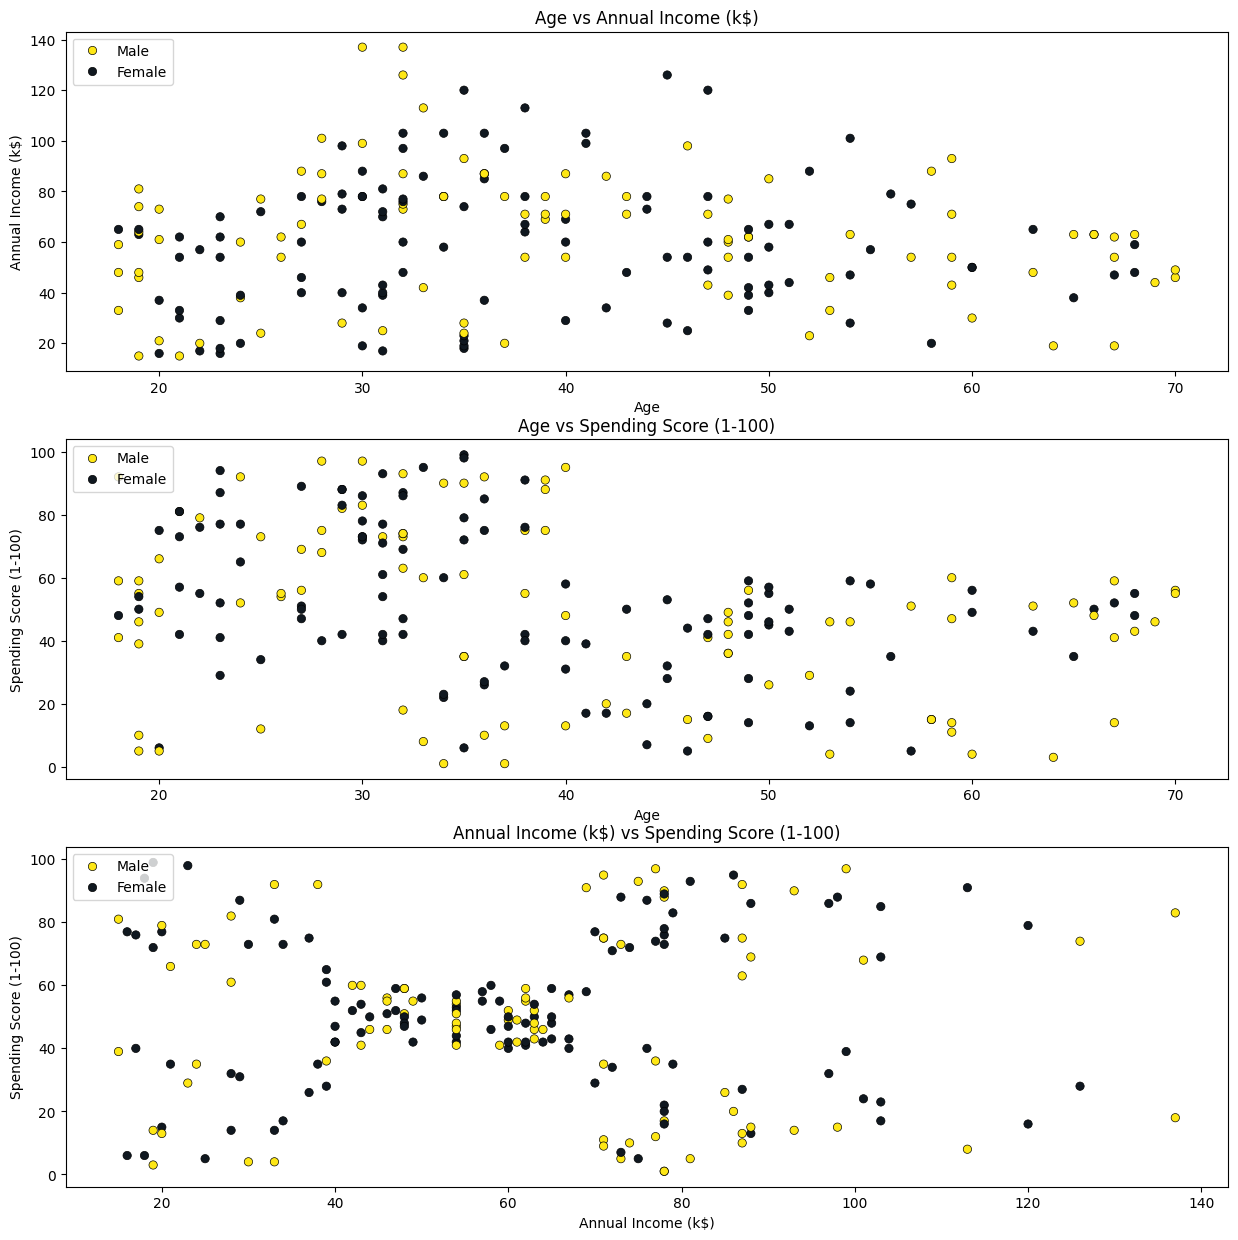

In [15]:
a = 0
fig,ax = plt.subplots(nrows = 3,ncols = 1,figsize = (15,15))
for i in range(len(numerical_features) - 1):
    for j in range(len(numerical_features)):
        if i != j and j > i:
            a += 1
            plt.subplot(3,1,a)
            sns.scatterplot(x = numerical_features[i],y = numerical_features[j],data = data,
                            hue = 'Gender',palette = colors,edgecolor = 'black');
            plt.legend(loc = 'upper left',)
            title = numerical_features[i] + ' vs ' + numerical_features[j]
            plt.title(title)

- 연간 소득 데이터 포인트는 모든 연령대에 걸쳐 존재하며, 성별은 유의미한 정보를 제공하지 않습니다.
- 지출 점수(1-100)의 경우, 20세에서 30세 사이의 연령대가 매우 높은 지출 습관을 보인다는 것을 명확히 알 수 있습니다.
- 30-40세 연령대는 고객의 지출 습관의 극단적인 측면을 모두 강조합니다. 40-70세 연령대 고객은 낮은 값으로 지출 습관의 반대편을 표시합니다.
- 연간 소득 대 지출 점수(1-100)에서 5개의 뚜렷한 그룹을 관찰할 수 있습니다. 연간 소득 값이 0-40인 경우, 데이터는 지출 점수(1-100)가 0-40인 고객 그룹을 강조 표시합니다.
- 이 1 극단치를 표시한 후, 데이터는 연간 소득이 40-70,000 사이이고 지출 점수(1-100)가 40-60 사이인 중간 고객 그룹을 강조합니다.
- 연간 소득 값이 70에서 140k 사이인 경우, 지출 점수(1-100) 값이 0에서 40, 60에서 100인 경우 두 그룹으로 나뉘는 극단값을 정의합니다.

## Summary of EDA

- 위의 쇼핑몰 데이터에서 여성 고객은 남성 고객보다 더 많습니다. 성별 데이터는 다른 기능에 따라 거의 고르게 분포되어 있습니다.
- 쇼핑몰 고객은 연령대별로 나눌 수 있습니다:
     *   20-30
     *   30-40
     *   40-70
- 두 성별의 평균 연간 소득은 약 60,000입니다. 이 값에는 세 가지 그룹이 표시됩니다:
     *   0 - 40k
     *   40 - 70k
     *   70~140,000.
- 여성의 지출 점수(1-100점)는 남성 고객보다 높습니다. 또한 고객을 세 그룹으로 나눌 수도 있습니다:
     *   0 - 40
     *   40 - 60
     *   60 - 100
- 위의 가치를 결합하여 쇼핑몰 고객을 세분화하여 특정 케이터링 서비스를 제공할 수 있습니다.

## Feature Engineering

### Correlation Matrix

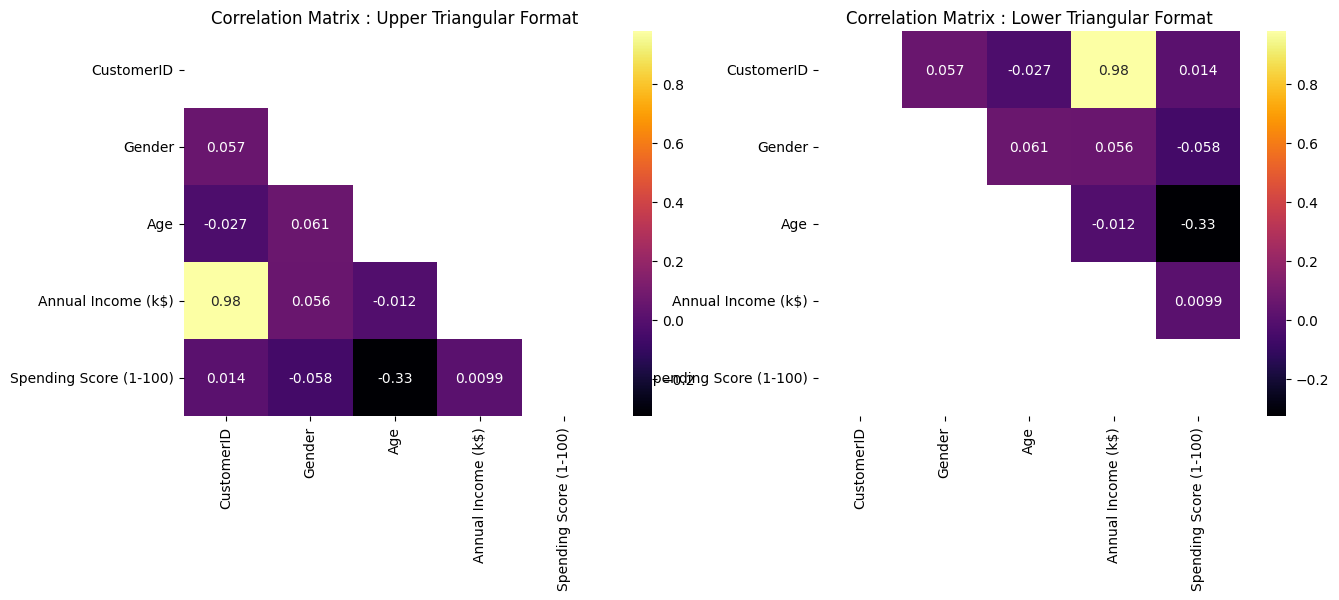

In [16]:
ut = np.triu(df1.corr())
lt = np.tril(df1.corr())

fig,ax = plt.subplots(nrows = 1, ncols = 2,figsize = (15,5))
plt.subplot(1,2,1)
sns.heatmap(df1.corr(),cmap = 'inferno',annot = True,cbar = 'True',mask = ut);
plt.title('Correlation Matrix : Upper Triangular Format');

plt.subplot(1,2,2)
sns.heatmap(df1.corr(),cmap = 'inferno',annot = True,cbar = 'True',mask = lt);
plt.title('Correlation Matrix : Lower Triangular Format');

df1.drop(columns = 'CustomerID',inplace = True)

- 표시된 두 행렬 모두 동일합니다. 시각화 목적으로만 수행됩니다. 이 트릭은 데이터셋에 너무 많은 기능이 있는 경우에 사용할 수 있습니다.
- 고객 ID는 고객의 연간 소득에 따라 오름차순으로 정렬되므로 연간 소득과 매우 높은 양의 상관관계를 보입니다. 모델링을 위해 고객 ID를 포함하지 않을 것입니다.
- 성별은 다른 특징들과 아무런 관계를 보이지 않습니다. 모든 값이 0으로 유지되는 거의 중립적입니다.
- 지출 점수(1-100)와 연령은 음의 상관관계를 나타냅니다. 즉, 한 특징의 값이 증가하면 다른 특징의 값이 감소하고 그 반대도 마찬가지입니다.
- 이 정보는 EDA 섹션에서 얻은 상관 행렬 값을 근거로 더 거슬러 올라갑니다.
- 이제 이러한 기능의 조합을 만들고 쇼핑몰 고객을 세분화할 수 있는 다양한 방법을 찾아 모델링 섹션으로 이동하겠습니다.

### Data Scalng:

머신 러닝 모델은 특징 값의 단위를 이해하지 못합니다. 입력을 단순한 숫자로만 취급하지만 해당 값의 진정한 의미를 이해하지 못합니다. 따라서 데이터를 확장할 필요가 있습니다.

데이터 확장에는 두 가지 옵션이 있습니다:

1) 정규화

2) 표준화

대부분의 알고리즘은 데이터가 정규 분포(Gaussian)라고 가정하기 때문에 정규화는 정규 분포를 나타내지 않는 특징에 대해 수행되며, 표준화는 정규 분포를 따르지만 다른 특징에 비해 값의 범위가 크거나 작은 특징에 대해 수행됩니다.

위 데이터셋에 대해 연령, 연간 소득(k$), 지출 점수(1-100)의 세 가지 특징에 대해 정규화를 수행했습니다. 성별 특징은 그대로 유지되었습니다.

In [17]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
mms = MinMaxScaler() # Normalization
ss = StandardScaler() # Standardization

# Label Encoding
df2 = df1.copy(deep = True)

# Normalization
df2['Age'] = mms.fit_transform(df2[['Age']])
df2['Annual Income (k$)'] = mms.fit_transform(df2[['Annual Income (k$)']])
df2['Spending Score (1-100)'] = mms.fit_transform(df2[['Spending Score (1-100)']])

- 원본 데이터셋과 정규화된 데이터셋에서 학습할 때 모델의 성능 차이를 강조하기 위해 원본 데이터셋의 복사본을 생성하고 정규화 변환을 적용합니다.

## Modeling

- 비지도 학습: 목표 변수/특징이 알려지지 않은 문제입니다. 비지도 학습 문제는 여러 번 측정하고 기저 질환을 알 수 없는 의료 분야에서 널리 발생합니다.
- 따라서 시각화 기법을 사용하여 패턴을 검색하면 표 형식의 데이터를 들여다보면 이해할 수 없는 기본적인 통찰력을 얻을 수 있습니다.
- 그러나 데이터셋의 크기가 너무 커서 특징이 너무 많아지면 데이터 시각화를 실행하는 것이 번거로울 수 있습니다. 따라서 범주형 특징을 지원하지 않는 K-평균 클러스터링 알고리즘으로 이동합니다.
- 데이터에서 클러스터/그룹을 찾는 역할을 하지만 수학적 접근 방식을 사용하는 비지도 학습을 처리할 때 가장 선호되는 알고리즘입니다:
     *   2개의 (assume k = 2) 중심체를 무작위로 선택
     * 중심점과 모든 데이터 포인트 사이의 거리가 계산됩니다.
     * 데이터 포인트가 중심점 중 하나에 더 가깝다면, 그 중심점과 그 반대로 표시됩니다.
     * 형성된 두 개의 클러스터에 대해, 중심점 중 하나로 그룹화된 데이터 포인트의 평균값을 계산한 후, 이 평균값을 새로운 클러스터로 정의합니다.
     * 이 과정은 양쪽 중심체가 고정점으로 수렴할 때까지 반복됩니다.
- k hyperparameter : 데이터를 나눌 클러스터 또는 그룹의 수를 정의합니다. k 값을 선택하기 위해 두 가지 통계적 검정을 사용
     *   Elbow Method: k 값 범위에 대한 제곱 오차의 합을 그래프로 표시하는 방법입니다. 이 그래프가 팔처럼 보이면 팔꿈치와 비슷한 값인 k를 선택합니다. 이 팔꿈치 값에서 제곱 값(관성)의 합은 선형적으로 감소하기 시작하므로 최적의 값으로 간주됩니다.
     *   Silhouette Score Method: 데이터 포인트가 서로 유사한 다른 데이터 포인트와 얼마나 잘 클러스터링되어 있는지를 기준으로 클러스터의 품질을 평가하는 방법입니다. 이 점수는 거리 공식을 사용하여 계산되며, 가장 높은 점수를 받은 k 값이 모델링에 선택됩니다.

In [18]:
# Dropping categorical feature
df1.drop(columns = 'Gender',inplace = True)
df2.drop(columns = 'Gender',inplace = True)

## Age - Annual Income (k$)

In [19]:
m1 = df1[['Age','Annual Income (k$)']].values # Original Dataset
m2 = df2[['Age','Annual Income (k$)']].values # Normalized Dataset

### Original Dataset:
Elbw Method & Silhouette Score Method:

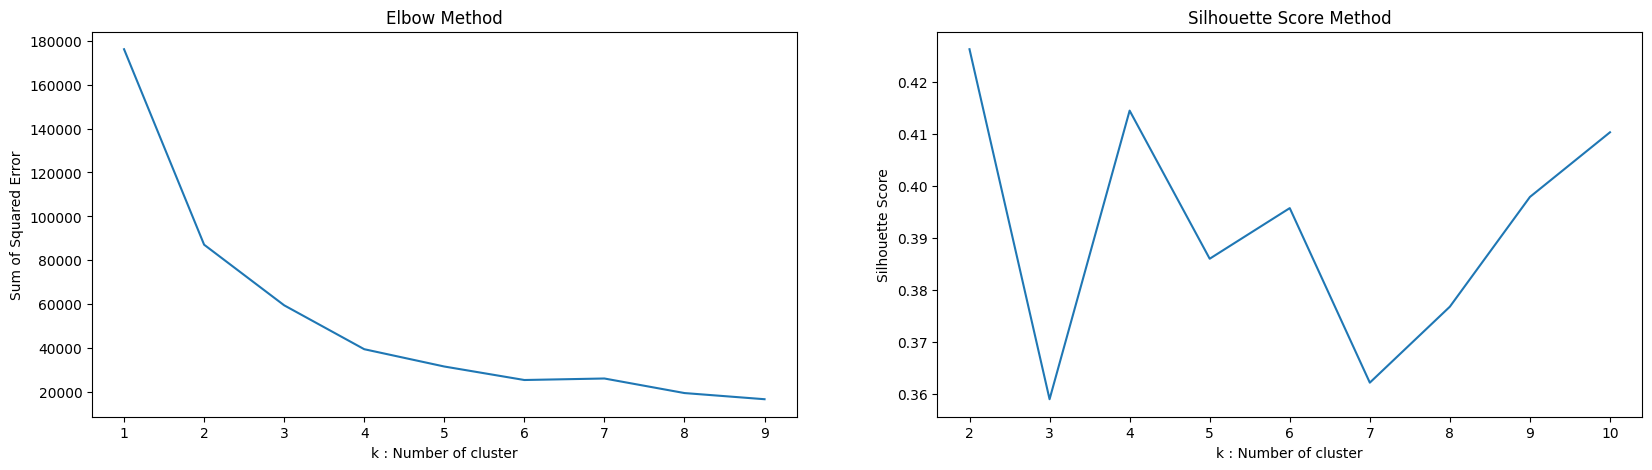

In [20]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- 위의 두 방법으로 선택한 k : Clusters = 4

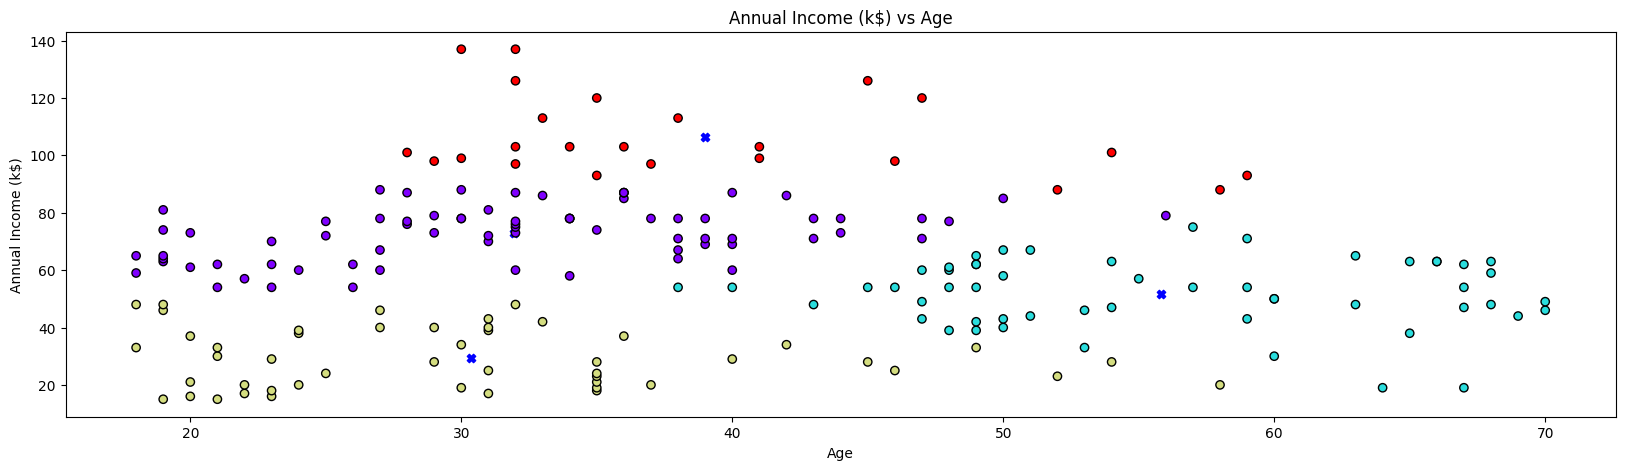

In [21]:
model = KMeans(n_clusters = 4,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Annual Income (k$)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

### Normalized Dataset:
Elbow Method & Silhouette Score Method:

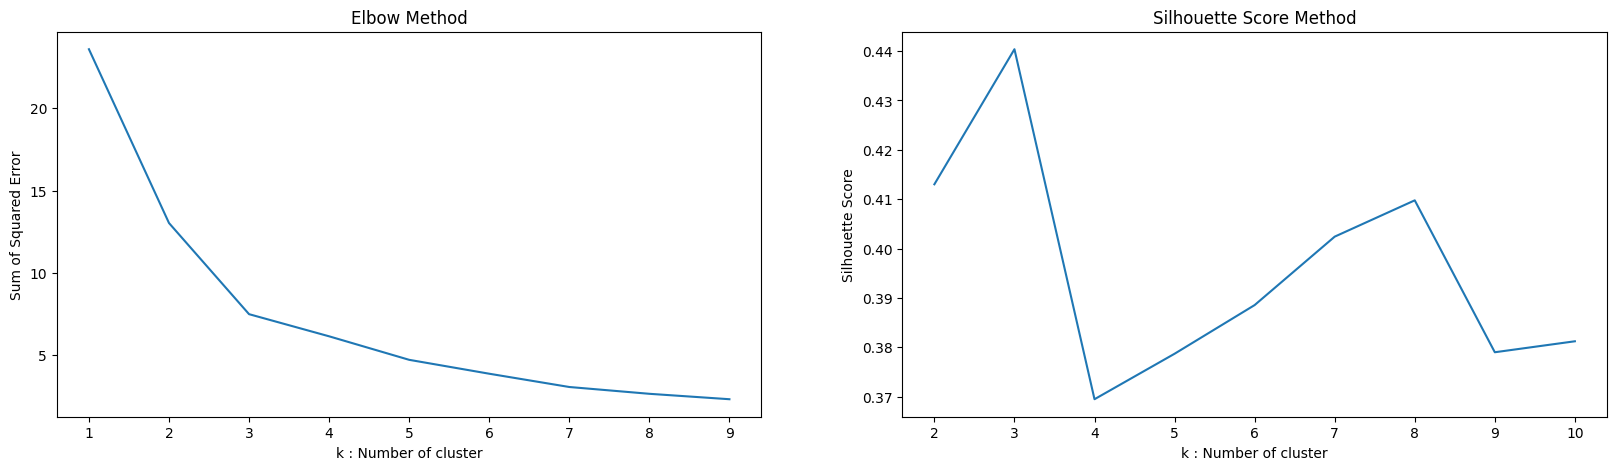

In [22]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- 위의 두 방법으로 선택한 k : Clusters = 3

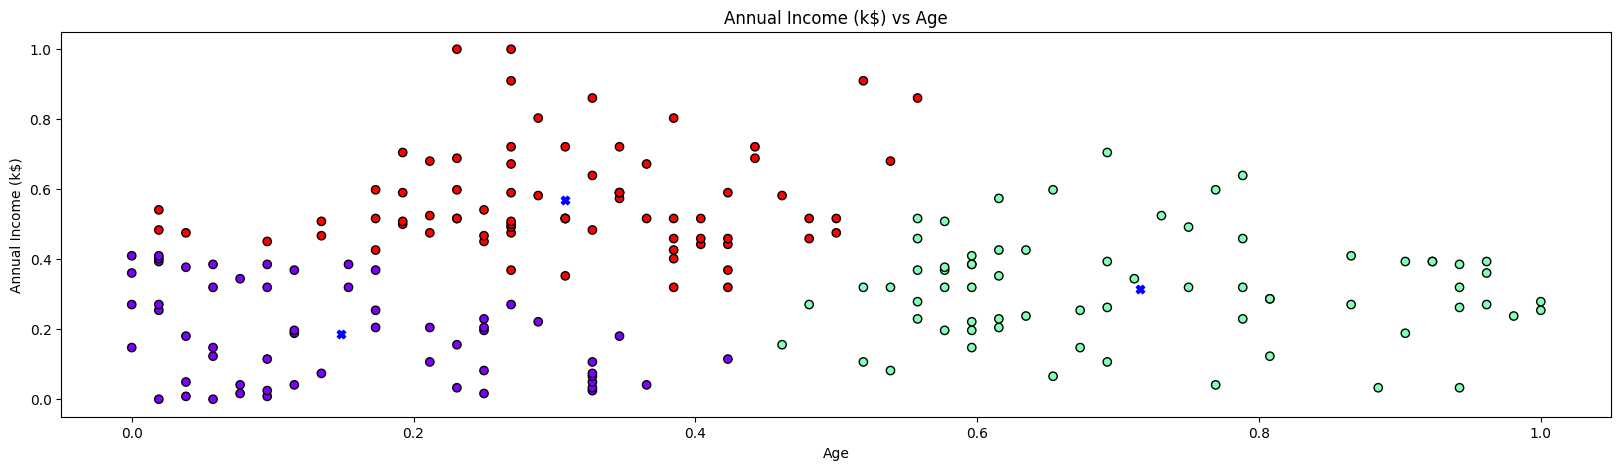

In [23]:
model = KMeans(n_clusters = 3,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Annual Income (k$)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

## Age - Spending Score (1-100)

In [24]:
m1 = df1[['Age','Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Age','Spending Score (1-100)']].values # Normalized Dataset

### Original Dataset:
Elbow Method & Silhouette Score Method:

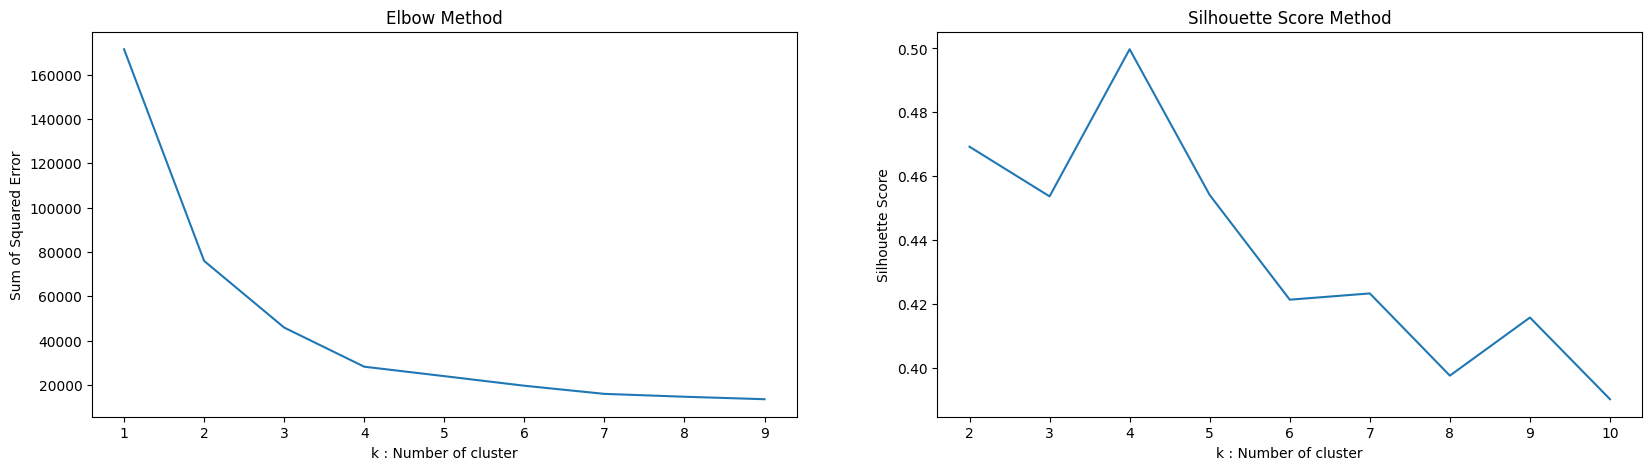

In [25]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- 위의 두 방법으로 선택한 k : Clusters = 4

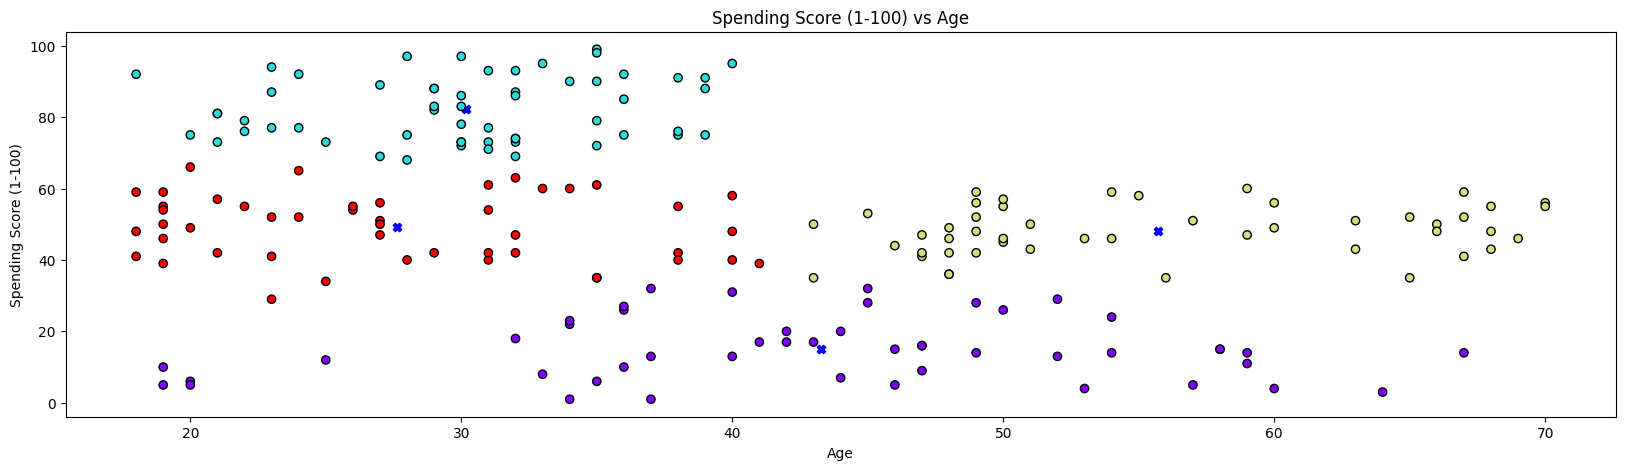

In [26]:
model = KMeans(n_clusters = 4,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

### Normalized Dataset:
Elbow Method & Silhouette Score Method:

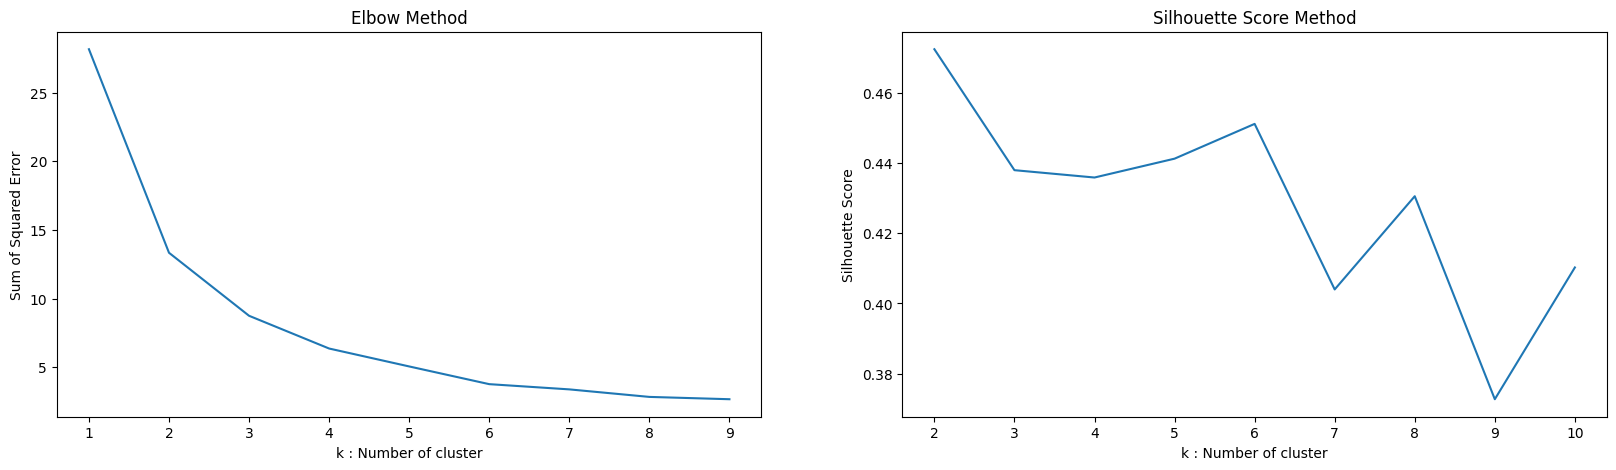

In [27]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- 위의 두 방법으로 선택한 k : Clusters = 6

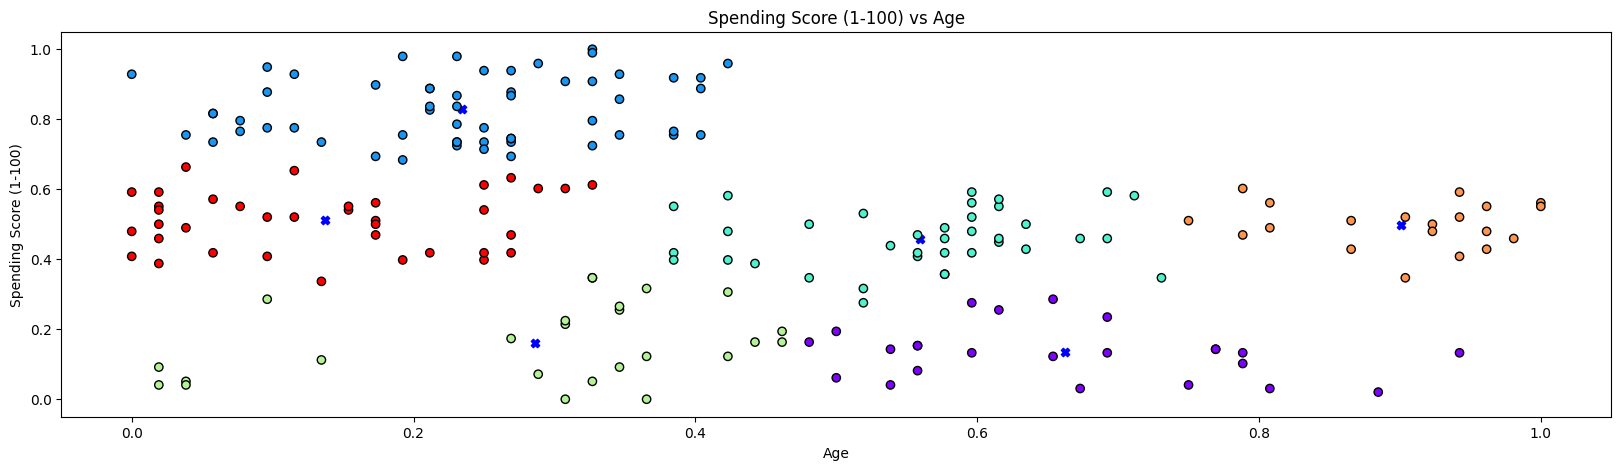

In [28]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

## Annual Income (k$) - Spending Score (1-100)

In [29]:
m1 = df1[['Annual Income (k$)', 'Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Annual Income (k$)', 'Spending Score (1-100)']].values # Normalized Dataset

### Original Dataset:
Elbow Method & Silhouette Score Method:

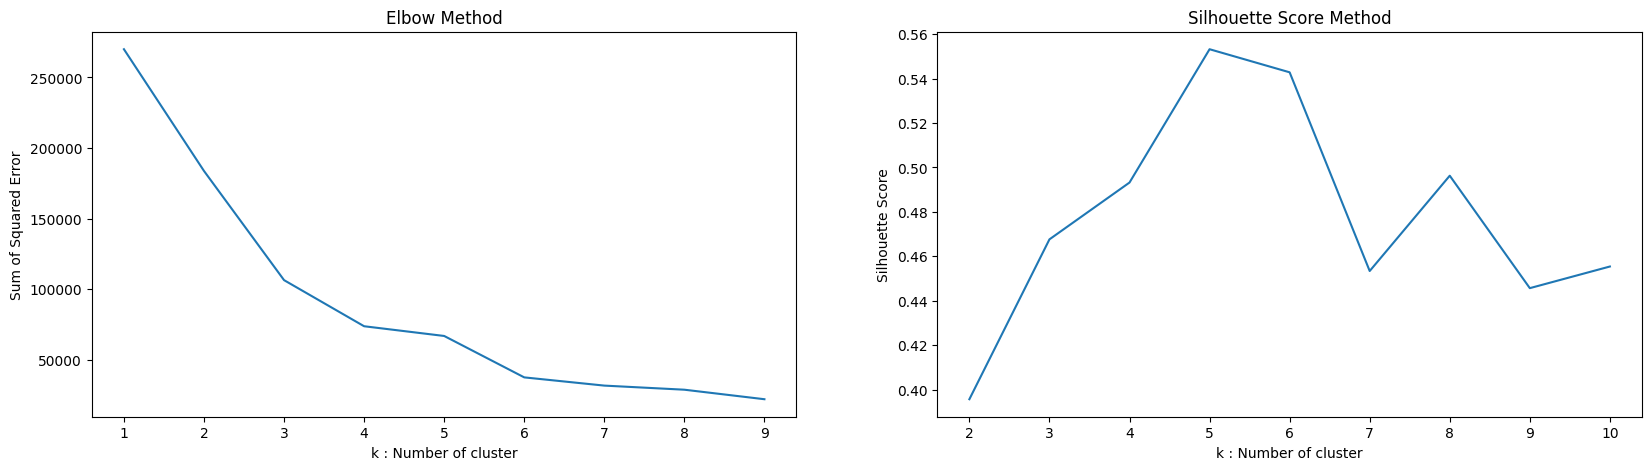

In [30]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- 위의 두 방법으로 선택한 k : Clusters = 5

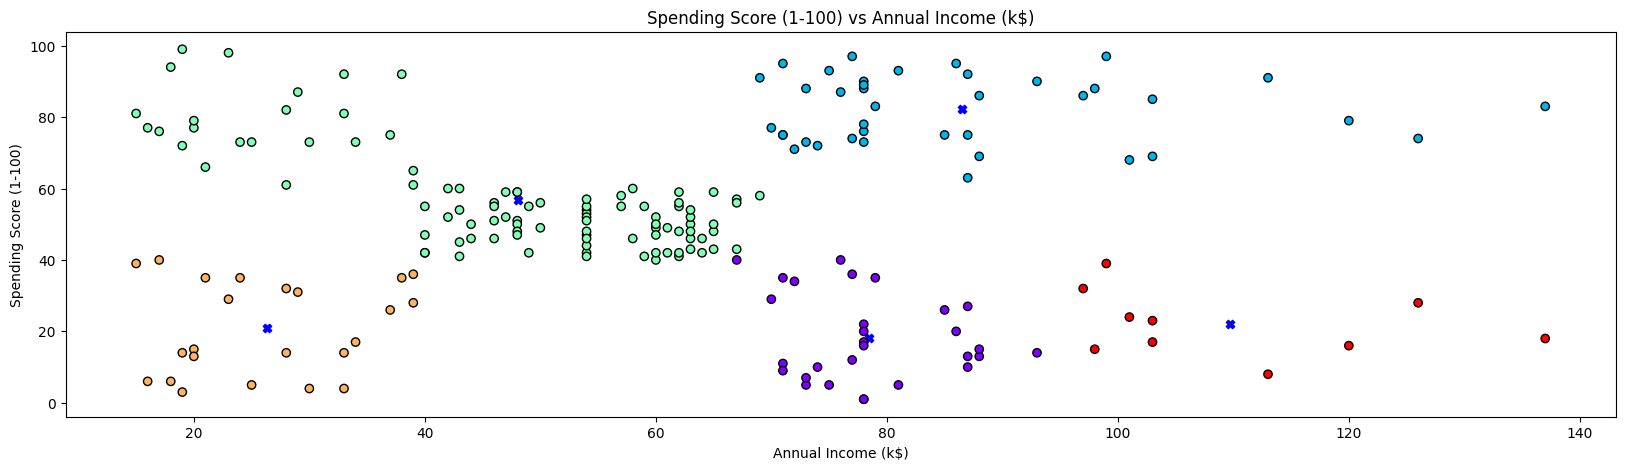

In [31]:
model = KMeans(n_clusters = 5,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show();

### Normalized Dataset:
Elbow Method & Silhouette Score Method:

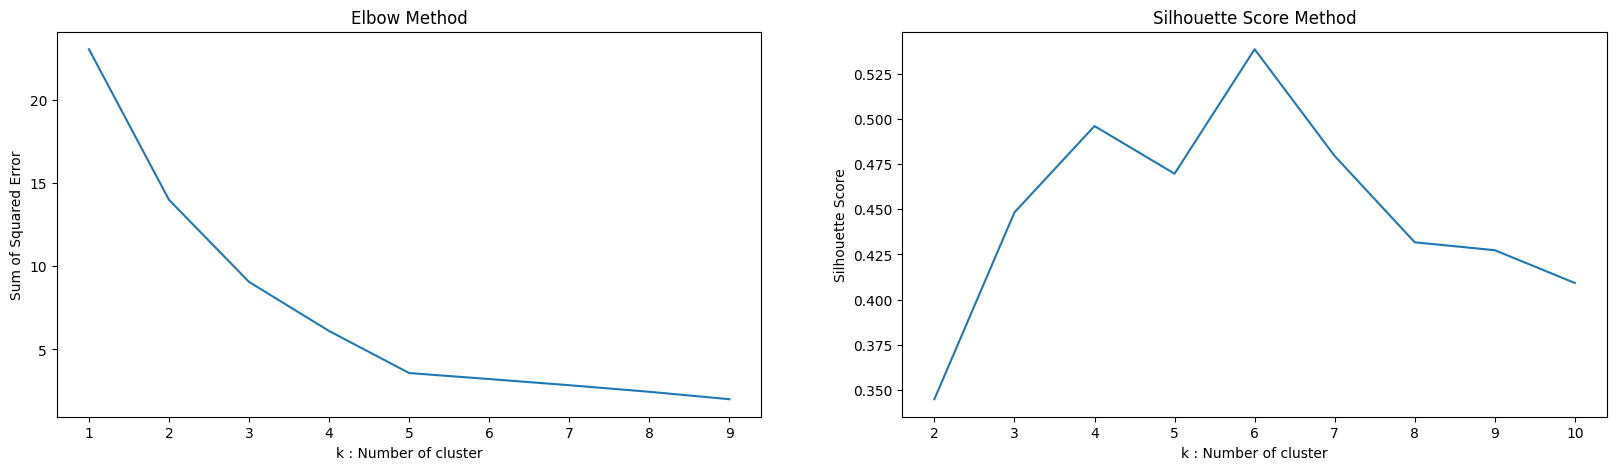

In [32]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- 위의 두 방법으로 선택한 k : Clusters = 5

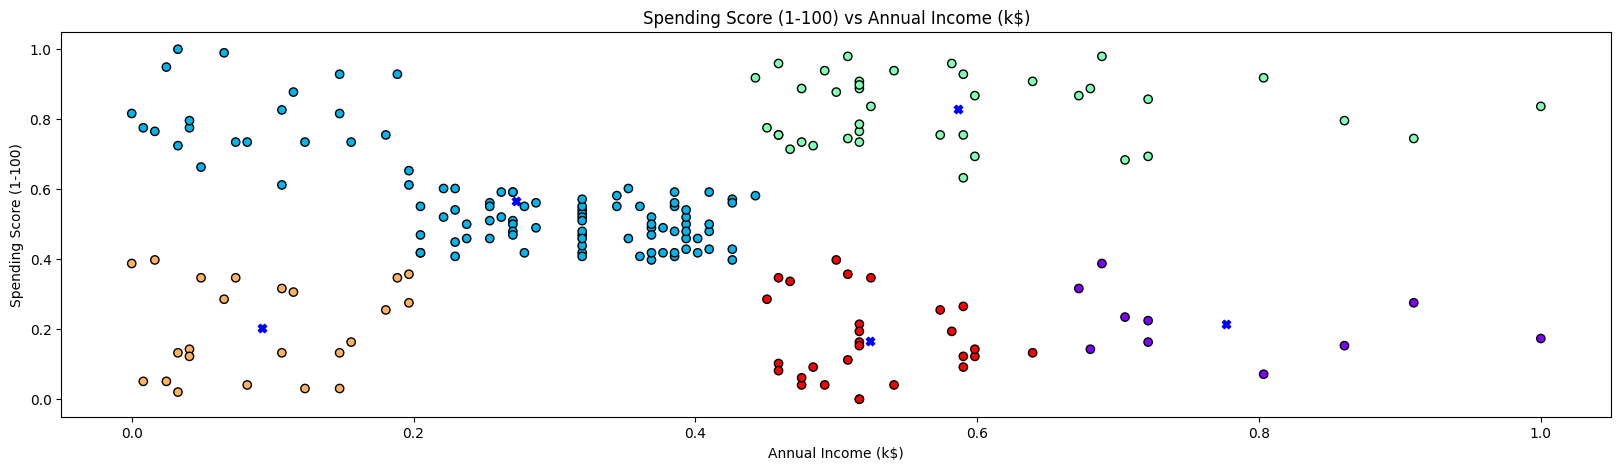

In [33]:
model = KMeans(n_clusters = 5,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show();

## Age - Annual Income (k$) - Spending Score (1-100)

In [34]:
m1 = df1[['Age','Annual Income (k$)','Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Age','Annual Income (k$)','Spending Score (1-100)']].values # Normalized Dataset

### Original Dataset:
Elbow Method & Silhouette Score Method:

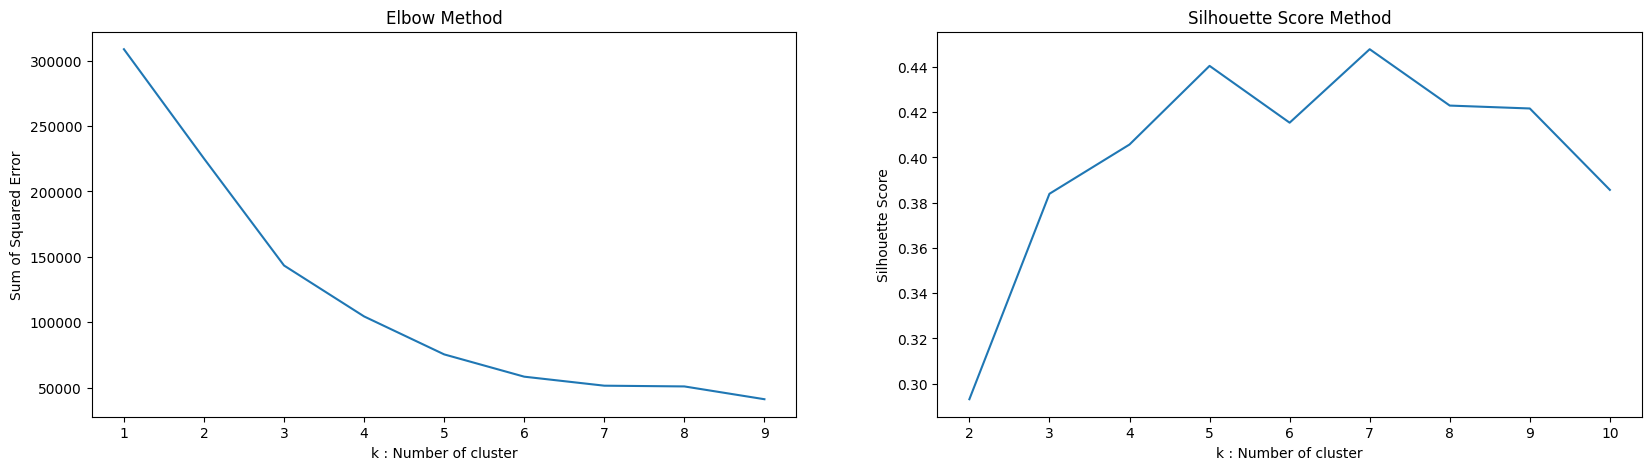

In [35]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- 위의 두 방법으로 선택한 k : Clusters = 6

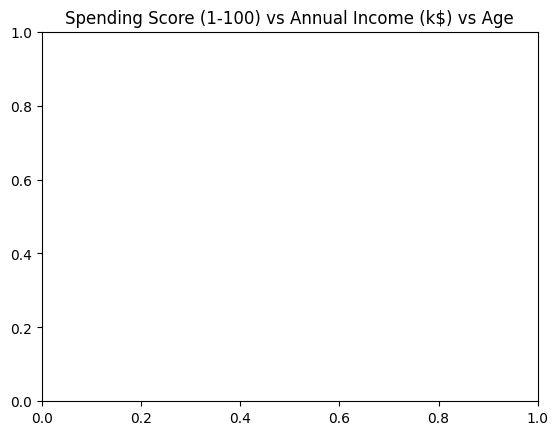

In [36]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

fig = plt.figure()
ax = Axes3D(fig)
x = np.array(df1['Annual Income (k$)'])
y = np.array(df1['Spending Score (1-100)'])
z = np.array(df1['Age'])
ax.scatter(centroids[:,0],centroids[:,1],centroids[:,2],marker="X", color = 'b')
ax.scatter(x,y,z,c = y)
plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
plt.show();

### Normalized Dataset:
Elbow Method & Silhouette Score Method:

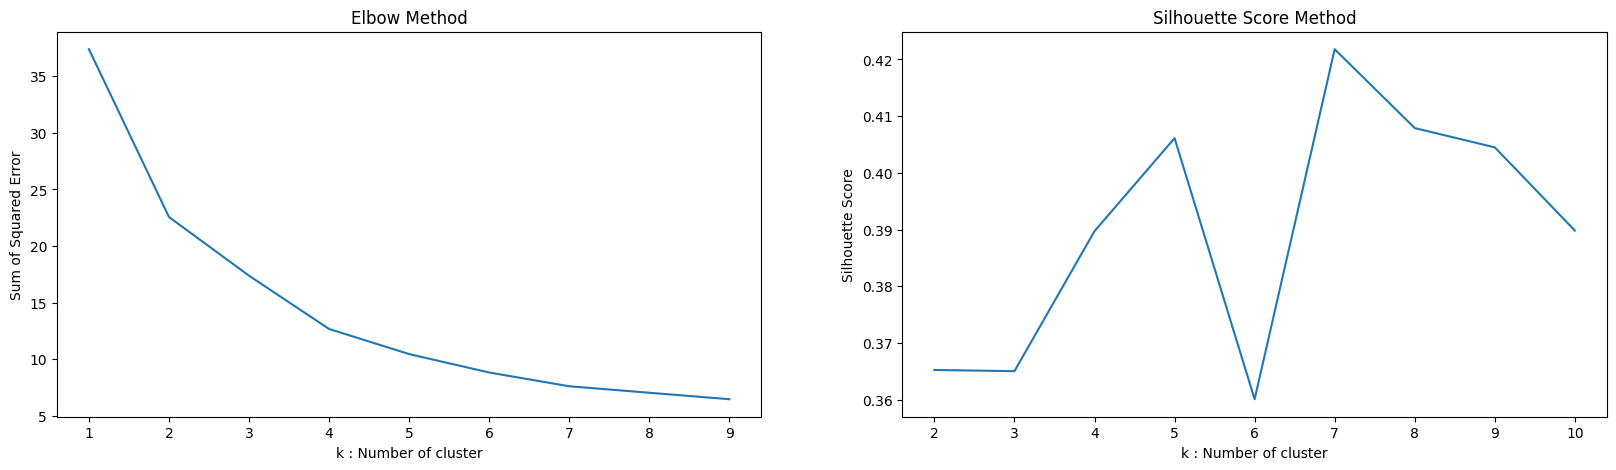

In [37]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- 위의 두 방법으로 선택한 k : Clusters = 6

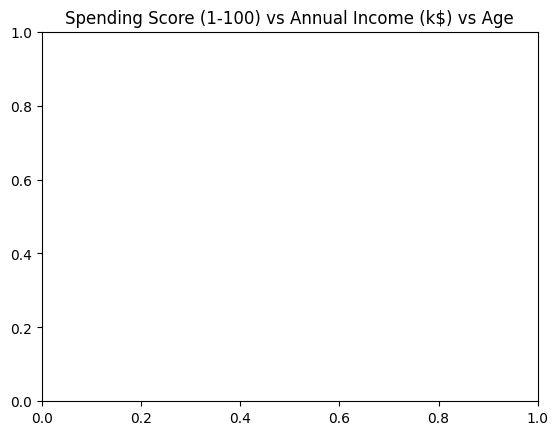

In [38]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

fig = plt.figure()
ax = Axes3D(fig)
x = np.array(df2['Annual Income (k$)'])
y = np.array(df2['Spending Score (1-100)'])
z = np.array(df2['Age'])
ax.scatter(centroids[:,0],centroids[:,1],centroids[:,2],marker = "X", color = 'b')
ax.scatter(x,y,z,c = y)
plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
plt.show();

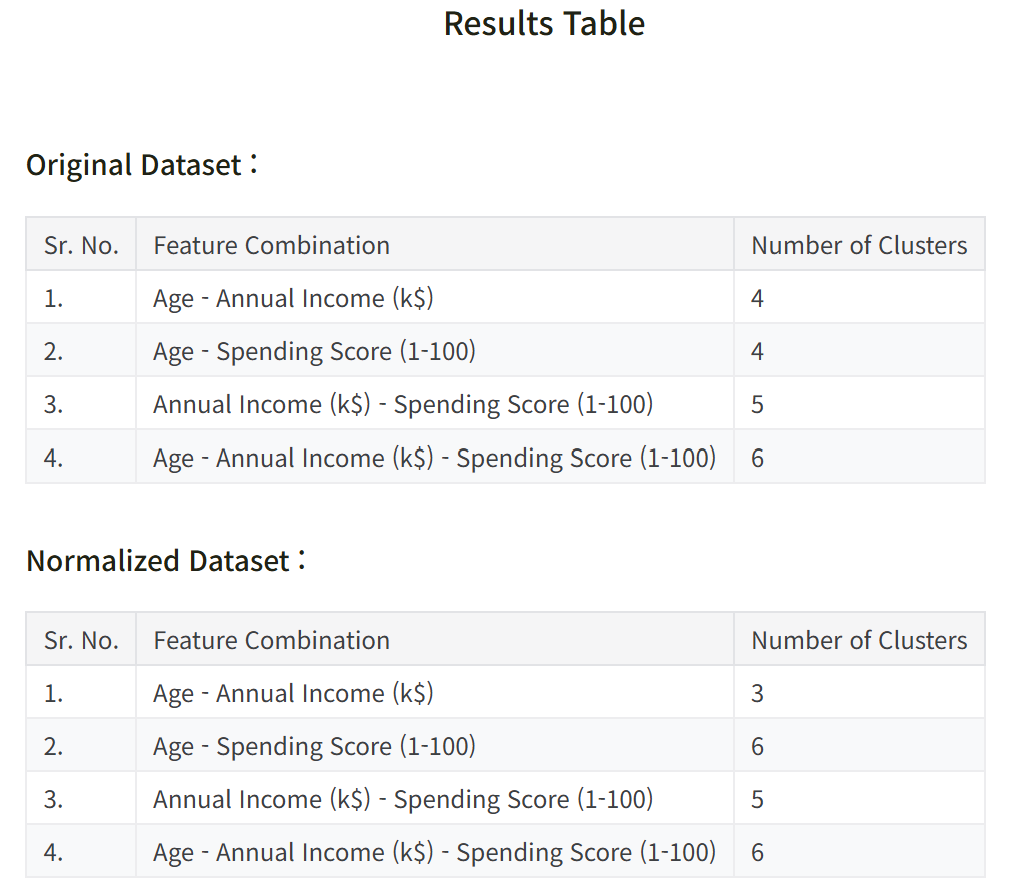

## Conclusion
- 이 데이터셋은 비지도 학습 문제를 해결하는 방법을 이해하는 데 매우 유용합니다. 이 데이터셋은 매출 증대를 위한 다양한 전략을 수립하는 데 활용할 수 있는 비즈니스 문제를 해결할 수 있는 기회를 제공합니다.
- 비지도 학습 문제의 경우, EDA는 데이터에서 숨겨진 인사이트를 찾아내는 데 매우 유용합니다. 그러나 데이터의 특징 수와 크기가 증가함에 따라 시각화의 복잡성이 장애물이 될 수 있습니다.
- K-평균 클러스터링 알고리즘의 경우 하이퍼파라미터 k의 선택이 중요하며 통계 테스트의 도움을 받아 수행됩니다. 이 경우 원본 데이터셋이나 정규화된 데이터셋으로 학습했을 때 모델 성능에는 큰 차이가 없습니다.